In [2]:
import copy
import time 
import torch
import sys, os
import numpy as np
import numpy.linalg as LA
from os.path import abspath, join, dirname, expanduser

sys.path.append(join(os.getcwd(), ".."))

from utils import *
from visuals import *
from pde_solvers import *

import matplotlib 
%matplotlib inline 

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/lekanmolu/Documents/ML-Control-Rob/soro/soro_spt/python/notes/../visuals/plotters.py:175: SyntaxWarning: invalid escape sequence '\|'
  single_plotter(ax2, qdbatch, f"$\|\dot{{\mathbf{{q}} }}\|$", title="Strain Velocity Field", color=next(colors), full_robot=True)
/home/lekanmolu/Documents/ML-Control-Rob/soro/soro_spt/python/notes/../visuals/plotters.py:175: SyntaxWarning: invalid escape sequence '\m'
  single_plotter(ax2, qdbatch, f"$\|\dot{{\mathbf{{q}} }}\|$", title="Strain Velocity Field", color=next(colors), full_robot=True)
/home/lekanmolu/Documents/ML-Control-Rob/soro/soro_spt/python/notes/../visuals/plotters.py:175: SyntaxWarning: invalid escape sequence '\|'
  single_plotter(ax2, qdbatch, f"$\|\dot{{\mathbf{{q}} }}\|$", title="Strain Velocity Field", color=next(colors), full_robot=True)


In [6]:
data_dir="/opt/SoRoSPT"
_labelsize=18
all_of_dem = os.listdir(data_dir)
print(all_of_dem)
fname = all_of_dem[1]


['slow_dyna_dump.pt', '092624_02_36_11_drag_cable_grav_10pcs_10.0N_spt_final.npz', '092524_21_53_25_drag_cable_grav_6pcs_10.0N_spt_final.npz', '092524_20_18_37_drag_cable_grav_6pcs_10.0N_spt_final.npz']


In [7]:
bundle   = load_file(fname, data_dir, verbose=True)
print(bundle.keys())

KeysView(NpzFile '/opt/SoRoSPT/092624_02_36_11_drag_cable_grav_10pcs_10.0N_spt_final.npz' with keys: fname, slow_solution, fast_solution, soltime, runtime...)


In [41]:
desired_strain = 0.5 
num_slow_pieces = bundle.num_slow_pieces
num_fast_pieces = bundle.num_fast_pieces

qd            = torch.tensor([[0, 0, 0, 1, desired_strain, 0]])
qd_dot        = torch.tensor([[0, 0, 0, 1, desired_strain, 0]]); 
qd_ddot        = torch.tensor([[0, 0, 0, 1, desired_strain, 0]])
    
gv.qd_slow = lambda t: torch.tile(qd.T, (num_slow_pieces, 1))
gv.qd_dot_slow = lambda t: torch.tile(qd_dot.T, (num_slow_pieces, 1))
gv.qd_ddot_slow = lambda t: torch.tile(qd_ddot.T, (num_slow_pieces, 1))

gv.qd_fast = lambda t: torch.tile(qd.T.to(t.device), (num_fast_pieces, 1))
gv.qd_dot_fast = lambda t: torch.tile(qd_dot.T.to(t.device), (num_fast_pieces, 1))
gv.qd_ddot_fast = lambda t: torch.tile(qd_ddot.T.to(t.device), (num_fast_pieces, 1))


import matplotlib.gridspec as Gridspec
fig = plt.figure(figsize=(16,9)); 
gs  = Gridspec.GridSpec(3, 2, fig)
ax  = [plt.subplot(gs[i]) for i in range(6)]
colors, gains, qbatch  = colors_and_gains(bundle, "pos", "fast")

_fontdict = {'fontsize':14, 'fontweight':'bold'}
tref = np.linspace(0, len(qbatch), len(qbatch)) #/1000
plt_len = len(tref)

for j in range(0, qbatch.shape[1]//6):
    ax[j].plot(tref[:plt_len], qbatch[:plt_len, slice(j, qbatch.shape[1], 6)], linewidth=2, color=next(colors), linestyle="--",label=f"Sec. {lidx+1}")
    ax[j].set_ylabel(rf"${{ {{\xi }} }}$",  fontdict=_fontdict)
    ax[j].set_xlabel(rf'Iterations',  fontdict=_fontdict)
    ax[j].set_title(rf"ax_{j+1}", _fontdict)

    ax[j].tick_params(axis='both', which='major', labelsize=8)
    ax[j].tick_params(axis='both', which='minor', labelsize=8)

    # ax[j].legend(loc='best', fontsize=25) #, prop=dict(weight='bold'))

plt.tight_layout()
plt.show ()



2.8254847058322694

TypeError: unsupported operand type(s) for /: 'NoneType' and 'int'

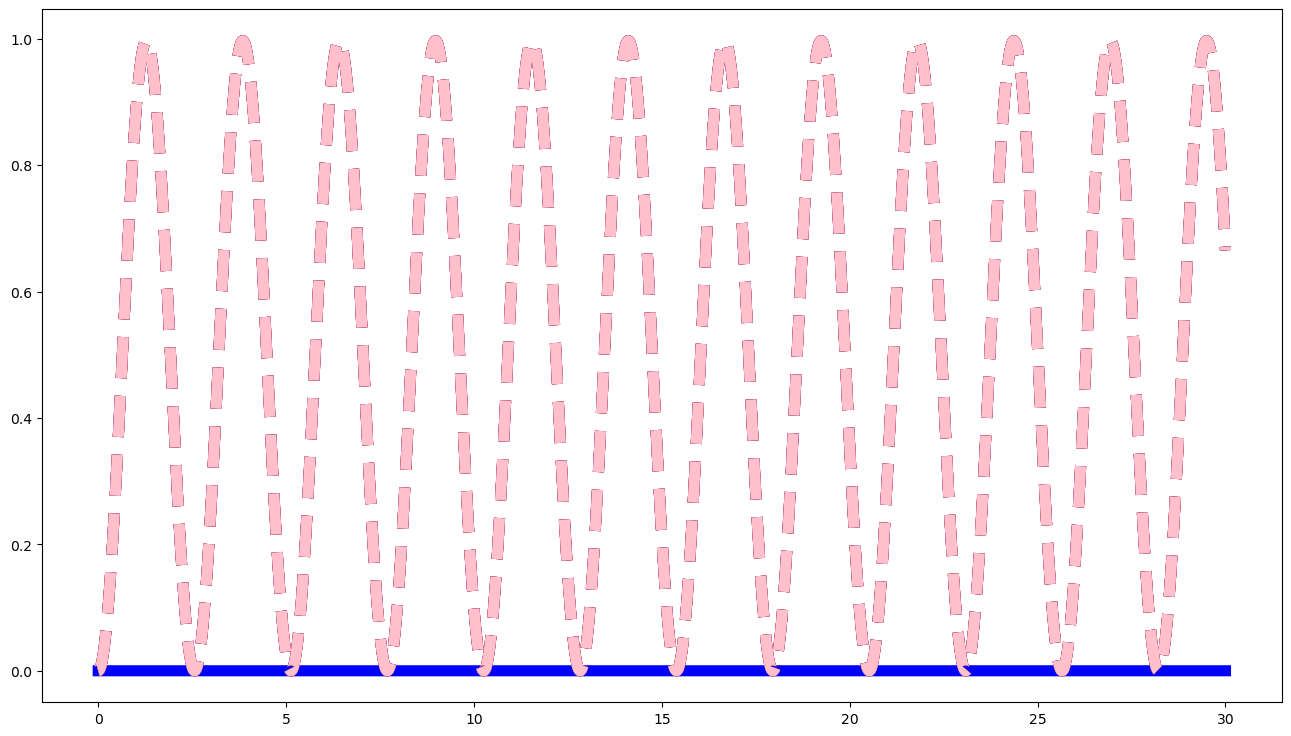

In [14]:

_fontdict = {'fontsize':34, 'fontweight':'bold'}

def get_fig_ax():
    fig = plt.figure(figsize=(16,9)); 
    ax = fig.add_subplot(1, 1, 1)

    return ax 

def colors_and_gains(bundle, plot_type="pos", piece_type="fast"):
    if strcmp(plot_type, "pos"):
        colors = iter(plt.cm.turbo_r(np.arange(0.15, bundle.num_fast_pieces, bundle.num_fast_pieces)))
        colors = iter(["red", "orange", "magenta", "olive", "purple", "pink", "green", "cyan", "black", "yellow"])
        # colors = iter(plt.cm.turbo_r(np.arange(0, bundle.pieces))) #*.25, bundle.pieces)))
    else:
        colors = iter(plt.cm.viridis_r(np.arange(0, bundle.num_fast_pieces))) #*.25, bundle.pieces)))
        colors = iter(["red", "orange", "magenta",  "green", "cyan", "black", "yellow", "olive", "purple", "pink"])

    runtime, controller =  bundle.runtime, bundle.controller 
    if strcmp(plot_type, "pos"):
        qbatch = bundle.qsecs.qbatch_fast if strcmp(piece_type, "fast") else bundle.qsecs.qbatch_slow 
    elif strcmp(plot_type, "vel"):
        qbatch = bundle.qsecs.qdbatch_fast if strcmp(piece_type, "fast") else bundle.qsecs.qdbatch_slow
    elif piece_type is None: # PD/PIC expts
        qbatch = bundle.qsecs.qbatch 


    if strcmp(controller, "spt"):
        gains = rf'Kp: {bundle.backstep_p}, Kd: {bundle.backstep_d}, ${{\mathcal{{F}}}}_p^y$: {bundle.tip_load}N.'
    elif strcmp(controller, "PD"):
        gains = rf'Kp: {bundle.Kp}, KD: {bundle.Kd}, ${{\mathcal{{F}}}}_p^y$: {bundle.tip_load}N.'
    elif strcmp(controller, "PID"):
        gains = rf'Kp: {bundle.Kp}, KD: {bundle.Kd}, Ki: {bundle.Ki}, ${{\mathcal{{F}}}}_p^y$: {bundle.tip_load}N.' 
    
    return colors, gains, qbatch 


def plot_axis_strains(ax, bundle, ref, _labelsize = 18, title=None, plot_type="pos",
                        ylabel=None, xlim=(-0.5, 10), ylim=[-0.02, 0.2], xy_pos=None,
                        _fontdict = {'fontsize':50, 'fontweight':'bold'}, piece_type="fast", \
                        plt_idx=4, lw=10, plt_len=None, save=False, annotate=True,  savename=None, \
                        save_dir = "/opt/SoRos/SoRoSPT/figures"):
   
    colors, gains, qbatch  = colors_and_gains(bundle, plot_type, piece_type)

    tref = np.linspace(0, len(qbatch), len(qbatch))/1000
    plt_len = len(tref) if plt_len is None else plt_len

    # plot the linear and angular strains of the first piece
    if isnumeric(ref):
        ax.plot(tref[:plt_len], [ref]*plt_len, linewidth=lw, linestyle="solid", color='blue', label=f"Ref.")    
        lidx = 0
        for i in range(plt_idx, qbatch.shape[1], 6):
            ax.plot(tref[:plt_len], qbatch[:plt_len,i], linewidth=lw, color=next(colors), linestyle="--",label=f"Sec. {lidx+1}")
            lidx += 1 
    else:       
        ax.plot(tref[:plt_len], np.sin(10*tref[:plt_len]), linewidth=lw, linestyle="solid", color='b', label=f"Ref.")
        # plot the trajs
        lidx = 0
        for i in range(plt_idx, qbatch.shape[1], 6):
            ax.plot(tref[:plt_len], qbatch[:plt_len,i], linewidth=lw, color=next(colors), linestyle="--",label=f"Sec. {lidx+1}")
            lidx += 1

    if annotate:
        if xy_pos is None:
            xy_pos = (np.mean(xlim), np.mean(ylim)-.04) if "vary" in title.lower() else (np.mean(xlim), np.mean(ylim))
        fontsize=35 if "vary" in title.lower() else 40
        ax.annotate(gains, xy=xy_pos, xycoords="data", va="center", ha="center", fontsize=fontsize, 
                        fontweight='bold', bbox=dict(boxstyle="round", fc="w"))
        
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.grid('on')
    
    ax.set_ylabel(ylabel,  fontdict= {'fontsize':45, 'fontweight':'bold'})
    ax.set_xlabel(rf'Solutions per centisecond',  fontdict= _fontdict)
    ax.set_title(title, _fontdict)

    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.tick_params(axis='both', which='minor', labelsize=28)
    
    ax.legend(loc='best', fontsize=25) #, prop=dict(weight='bold'))

    # if save:
    #     fig_batch = plt.gcf()
    #     fig_batch.tight_layout()
    #     if not savename:
    #         fn = bundle.fname.split("_")
    #         savename = "_".join([x for x in (fn[0], *fn[4:-1])])
    #         # savename = f"{controller}"
    #         # if bundle.cable:
    #         #     savename += f"_cable"
    #         # if bundle.drag:
    #         #     savename += f"_drag"
    #         # if "vary" in title.lower():
    #         #     savename += f"_varying"
    #     print(f"savename: {savename}")
    #     fig_batch.savefig(join(save_dir, savename+".eps"), bbox_inches='tight',  \
    #         facecolor='w', format="eps", dpi=1000, transparent=True)
        
ax = get_fig_ax()
bundle = load_file(fname, data_dir)

plot_axis_strains(ax, bundle, 0.0, _labelsize, plot_type="pos", piece_type="fast", \
                title=f'{bundle.controller} Controller', lw=8, annotate=True, xy_pos=None, \
                ylabel=r'${{ \dot {{\xi_{y} }} }}$',  ylim=None, xlim=None, save=True)

plt.show()

# plot_axis_strains(ax, bundle, 0.0, _labelsize, plot_type="vel", piece_type="slow", \
#                 title=f'{bundle.controller} Controller', lw=8, annotate=True, xy_pos=None, \
#                 ylabel=r'${{ \dot {{\xi_{y} }} }}$',  ylim=(-0.1, 0.5), xlim=(0.03, 2.50), save=True)
# plt.show()


In [31]:

# fig = plt.figure(figsize=(16,9)); 
# ax = fig.add_subplot(3, 2, 1)
bundle.qd 

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

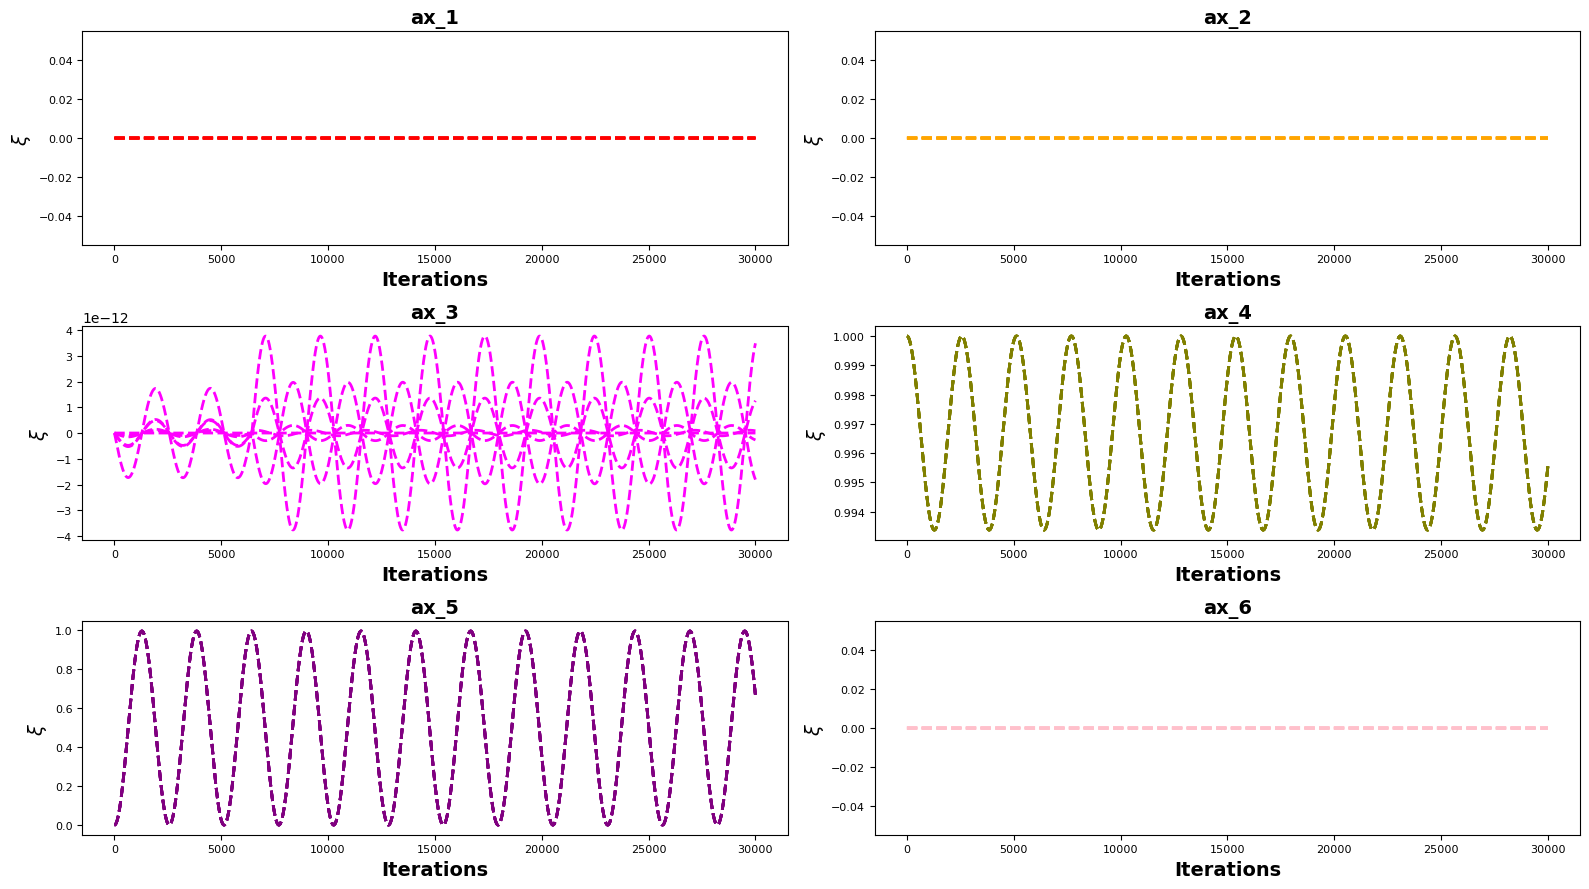

In [33]:

import matplotlib.gridspec as Gridspec
fig = plt.figure(figsize=(16,9)); 
gs  = Gridspec.GridSpec(3, 2, fig)
ax  = [plt.subplot(gs[i]) for i in range(6)]
colors, gains, qbatch  = colors_and_gains(bundle, "pos", "fast")

_fontdict = {'fontsize':14, 'fontweight':'bold'}
tref = np.linspace(0, len(qbatch), len(qbatch)) #/1000
plt_len = len(tref)

for j in range(0, qbatch.shape[1]//6):
    ax[j].plot(tref[:plt_len], qbatch[:plt_len, slice(j, qbatch.shape[1], 6)], linewidth=2, color=next(colors), linestyle="--",label=f"Sec. {lidx+1}")
    ax[j].set_ylabel(rf"${{ {{\xi }} }}$",  fontdict=_fontdict)
    ax[j].set_xlabel(rf'Iterations',  fontdict=_fontdict)
    ax[j].set_title(rf"ax_{j+1}", _fontdict)

    ax[j].tick_params(axis='both', which='major', labelsize=8)
    ax[j].tick_params(axis='both', which='minor', labelsize=8)

    # ax[j].legend(loc='best', fontsize=25) #, prop=dict(weight='bold'))

plt.tight_layout()
plt.show ()



In [ ]:
bundle.

In [ ]:
bundle.gv

fname: 072423_10_30_23_with_cable_4_pieces_tipload.10N_PD_Control.npz, strain_goal(q^d): None
num_pieces: 4 num_sections: 41, drag: False, cable: True
runtime: 3513.3881 mins or  58.5565 hours.
controller: PD | Kp: 4.0 | Kd: 5.5 | tip_load: 10
savename: 072423_with_cable_4_pieces_tipload.10N_PD


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


fname: 072723_18_51_22_with_drag_4_pieces_tipload.10N_PD_Control.npz, strain_goal(q^d): None
num_pieces: 4 num_sections: 41, drag: True, cable: False
runtime: 661.5728 mins or  11.0262 hours.
controller: PD | Kp: 4.0 | Kd: 0.5 | tip_load: 10
savename: 072723_with_drag_4_pieces_tipload.10N_PD


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


fname: 072423_01_09_27_4_pieces_tipload.10N_PD_Control.npz, strain_goal(q^d): None
num_pieces: 4 num_sections: 41, drag: False, cable: False
runtime: 277.4110 mins or  4.6235 hours.
controller: PD | Kp: 3.5 | Kd: 0.34 | tip_load: 10
savename: 072423_4_pieces_tipload.10N_PD


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


fname: 090623_11_02_36_with_cable_10_pieces_tipload.0.2N_PD_Control.npz, strain_goal(q^d): None
num_pieces: 4 num_sections: 41, drag: 0, cable: 1
runtime: 3856.9614 mins or  64.2827 hours.
controller: PD | Kp: 50.0 | Kd: 5.42 | tip_load: 0.2
savename: 090623_with_cable_10_pieces_tipload.0.2N_PD


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


fname: 091023_08_55_01_with_cable_10_pieces_tipload.1.0N_PD_Control.npz, strain_goal(q^d): None
num_pieces: 4 num_sections: 41, drag: 0, cable: 1
runtime: 3087.4334 mins or  51.4572 hours.
controller: PD | Kp: 1.5 | Kd: 5.8 | tip_load: 1.0
savename: 091023_with_cable_10_pieces_tipload.1.0N_PD


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


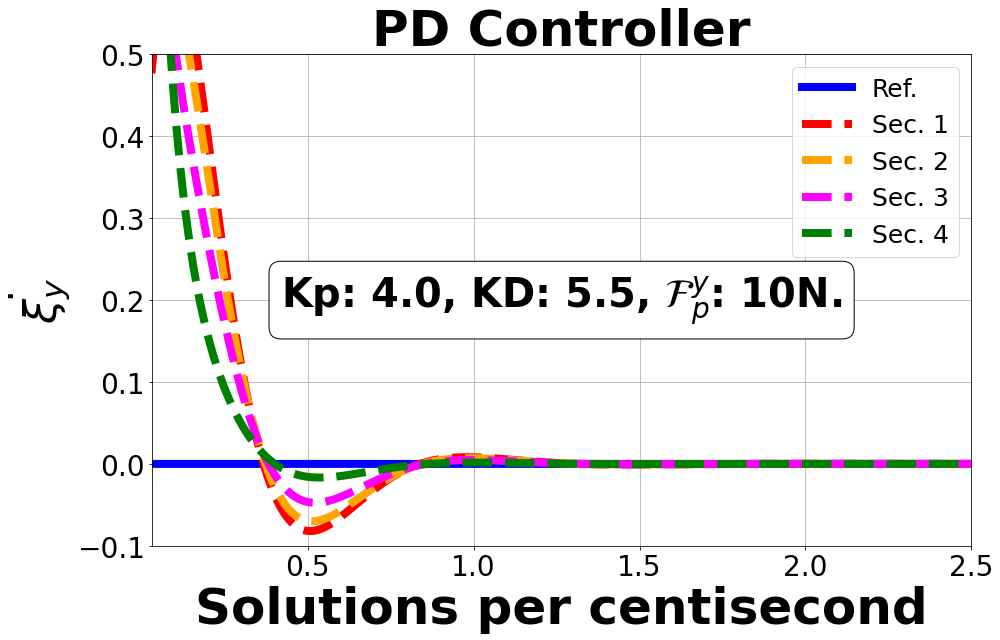

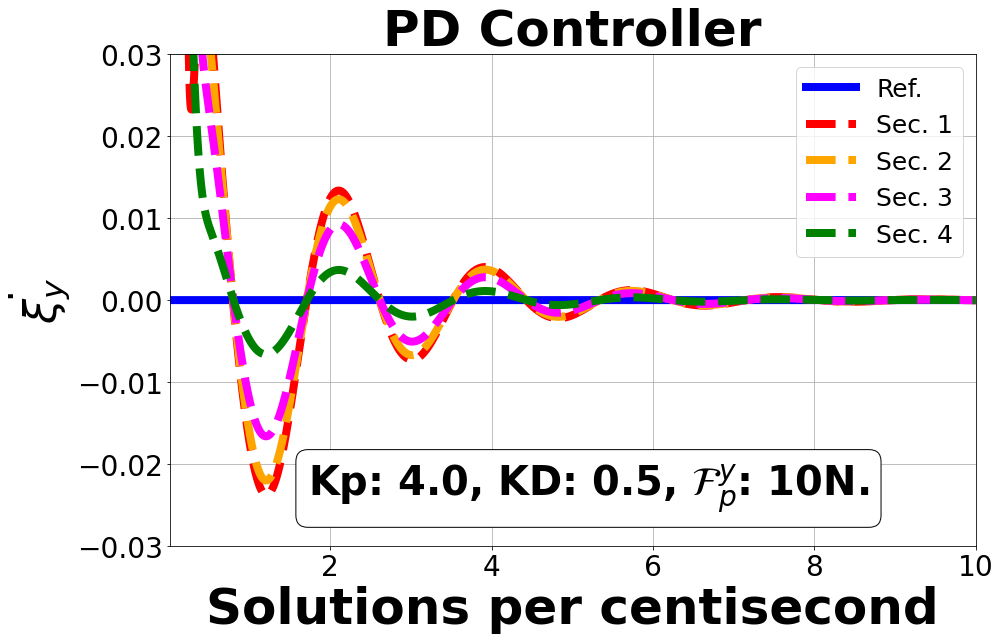

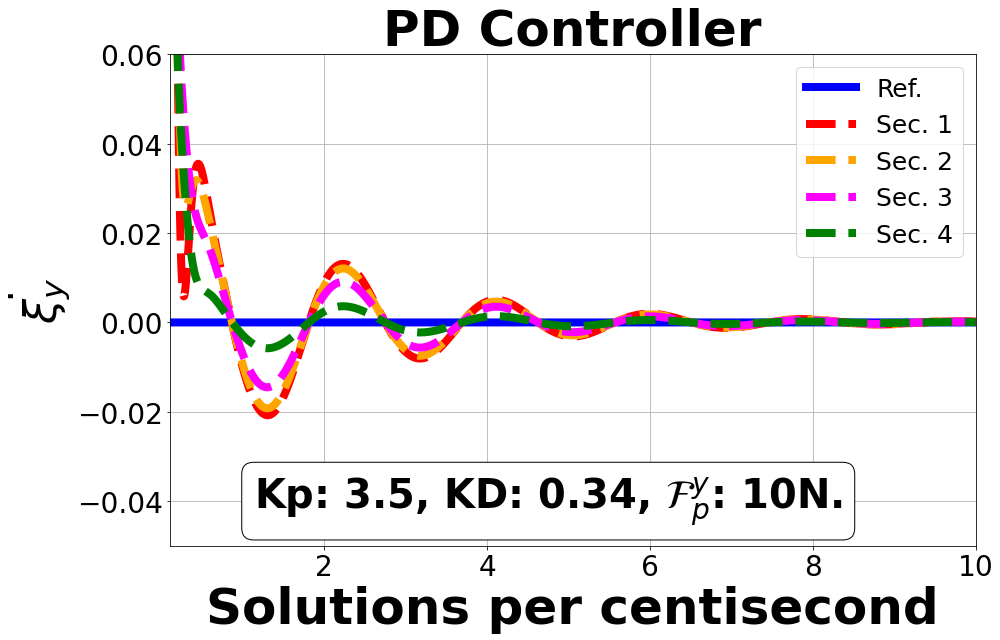

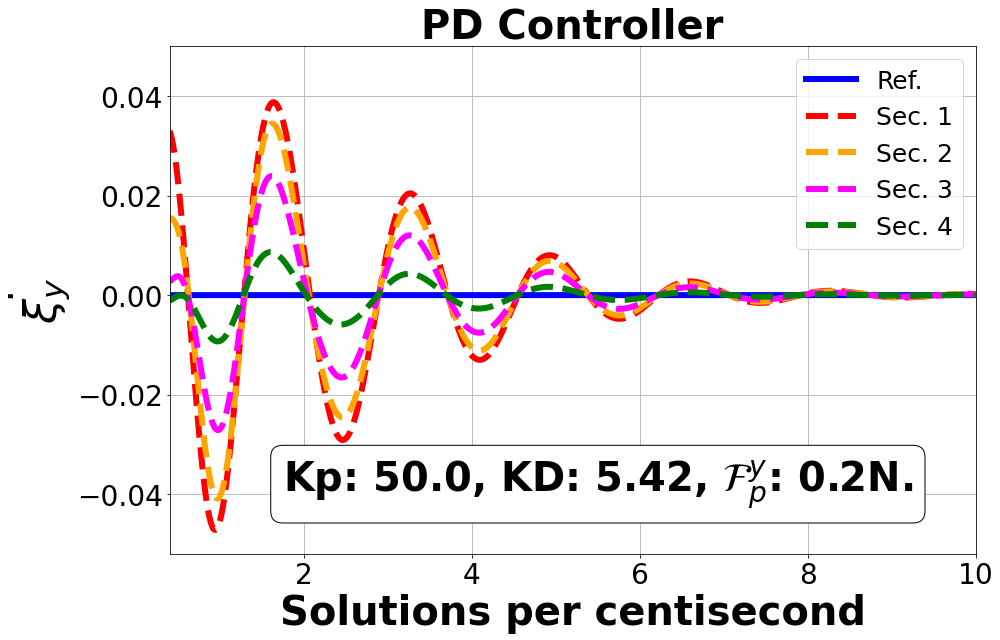

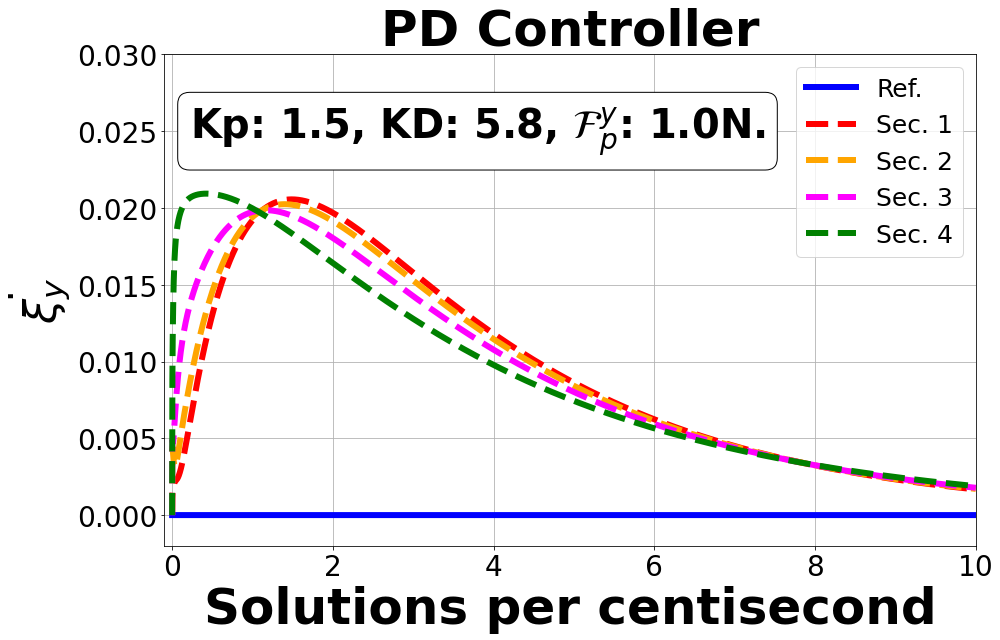

In [15]:


def do_plot(data_dir="/opt/SoRoSPT/", _labelsize=18):
    # plt.ion()

    ax = get_fig_ax()
    fname = "072423_10_30_23_with_cable_4_pieces_tipload.10N_PD_Control.npz"
    bundle = load_file(fname, data_dir)
    plot_axis_strains(ax, bundle, 0.0, _labelsize, plot_type="vel", \
                    title=f'{bundle.controller} Controller', lw=8, annotate=True, xy_pos=None, \
                    ylabel=r'${{ \dot {{\xi_{y} }} }}$',  ylim=(-0.1, 0.5), xlim=(0.03, 2.50), save=True)

    ax = get_fig_ax()
    fname = "072723_18_51_22_with_drag_4_pieces_tipload.10N_PD_Control.npz"
    bundle = load_file(fname, data_dir)
    plot_axis_strains(ax, bundle, 0.0, _labelsize, title=f'{bundle.controller} Controller', plot_type="vel", lw=8, \
                annotate=True, xy_pos=(5.2, -0.023), ylabel=r'${{ \dot {{\xi_{y} }} }}$', xlim=(0.01, 10.00), \
                ylim=[-0.03, 0.03], plt_len=10000, save=True)

    ax = get_fig_ax()
    fname = "072423_01_09_27_4_pieces_tipload.10N_PD_Control.npz"
    bundle = load_file(fname, data_dir)
    plot_axis_strains(ax, bundle, 0.0, _labelsize, title=f'{bundle.controller} Controller', plot_type="vel", annotate=True,
                 lw=8, ylabel=r'${{ \dot {{\xi_{y} }} }}$', xlim=(0.100, 10), ylim=[-0.05, 0.06], plt_len=10000, 
                 save=True, xy_pos=(4.75, -0.04))
    
    ax = get_fig_ax()
    fname = "090623_11_02_36_with_cable_10_pieces_tipload.0.2N_PD_Control.npz"
    bundle = load_file(fname, data_dir)
    plot_axis_strains(ax, bundle, 0.0, _labelsize, title=f'{bundle.controller} Controller', plot_type="vel", annotate=True,
                 xy_pos=(5.5, -0.038), 
                plt_idx=3, ylabel=r'${{ \dot {{\xi_{y} }} }}$',  xlim=(0.400, 10.000), ylim=[-0.052, 0.05], lw=6, 
                 _fontdict = {'fontsize':40, 'fontweight':'bold'}, save=True)

    ax = get_fig_ax()
    fname="091023_08_55_01_with_cable_10_pieces_tipload.1.0N_PD_Control.npz"
    bundle = load_file(fname, data_dir)
    qbatch, plt_idx = bundle.qbatch, 5
    plot_axis_strains(ax, bundle, 0.0, _labelsize, title=f'{bundle.controller} Controller', plot_type="vel", 
                plt_len=len(qbatch), plt_idx=plt_idx, ylabel=r'${{ \dot {{\xi_{y} }} }}$',  xlim=(-0.1, 10), annotate=True,
                ylim=[-.002, 0.03], lw=6, xy_pos=(3.8, 0.025), save=True)                 

do_plot()                